## Model 1: Decision Tree Classifier

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    recall_score, precision_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

Fetching dataset...
Loaded 999,999 rows.

Fraud rate: 1.10%
Fraud cases: 11,029  |  Legit cases: 988,970

Train size: 799,999  |  Test size: 200,000
Train fraud count: 8,823  |  Test fraud count: 2,206

Processed train shape: (799999, 51)
Processed test shape:  (200000, 51)

 Baseline Decision Tree
Accuracy:  0.9796
Recall:    0.0784
Precision: 0.0777
F1-Score:  0.0781

Hyperparameter Tuning (GridSearchCV, memory-safe version)
Fitting 3 folds for each of 96 candidates, totalling 288 fits

Best params: {'class_weight': {0: 1, 1: 10}, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10}
Best CV F1:  0.1485

 Tuned Decision Tree Evaluation
Accuracy:  0.9652
Recall:    0.2625
Precision: 0.0979
F1-Score:  0.1426
ROC-AUC:   0.8051

Confusion Matrix:
[[192461   5333]
 [  1627    579]]

Classification Report:
              precision    recall  f1-score   support

       Legit     0.9916    0.9730    0.9822    197794
       Fraud     0.0979    0.2625    0.1426      2206

    accuracy

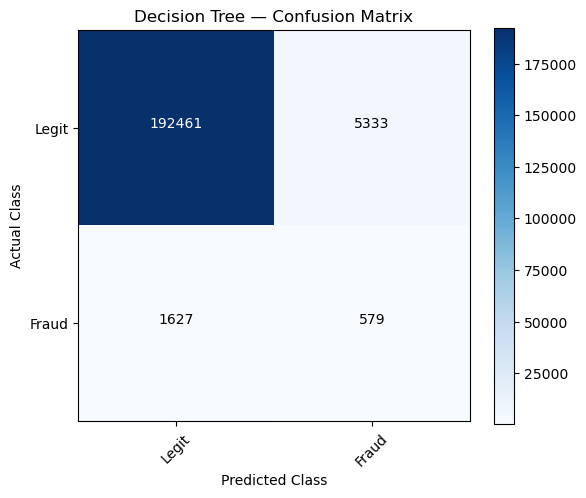

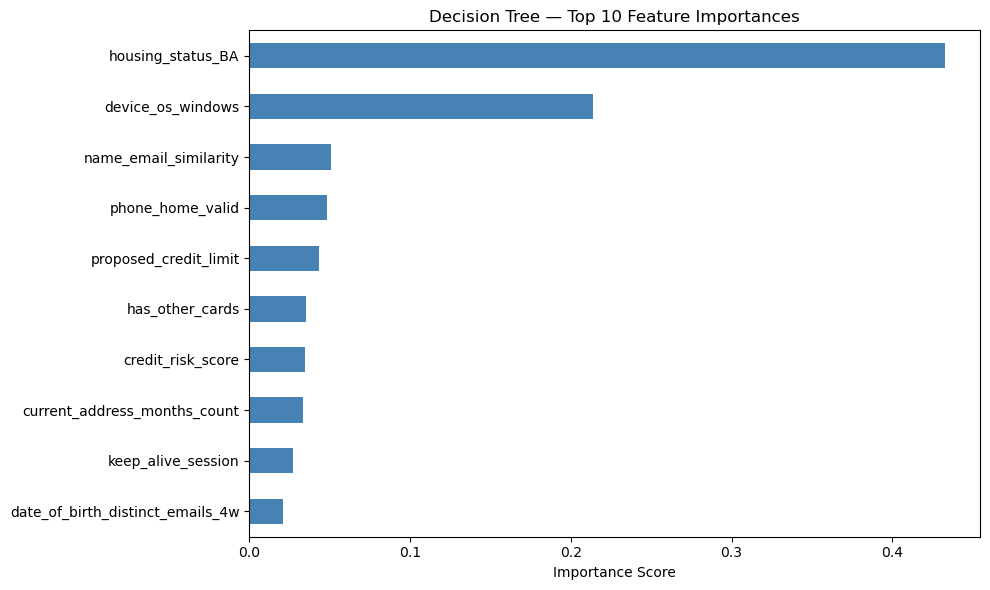


 Decision Tree complete
  Best params: {'class_weight': {0: 1, 1: 10}, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10}
  Test F1: 0.1426  |  ROC-AUC: 0.8051  |  Recall: 0.2625


In [2]:
# Load Data

key_path = "../../../fraud-detection-key.json"

if os.path.exists(key_path):
    client = bigquery.Client.from_service_account_json(key_path)
    query = "SELECT * FROM `csci-4022.CSCI.fraud_data`"
    print("Fetching dataset...")
    df = client.query(query).to_dataframe()
    print(f"Loaded {len(df):,} rows.")
else:
    print("Key file not found.")
    raise FileNotFoundError("BigQuery key not found at: " + key_path)

# Preprocessing

# Columns where -1 is a sentinel for missing (not a real value)
sentinel_cols = ["prev_address_months_count", "bank_months_count"]
for col in sentinel_cols:
    df[col] = df[col].replace(-1, np.nan)

# Target and features
y = df["fraud_bool"]
X = df.drop(columns=["fraud_bool"])

print(f"\nFraud rate: {y.mean()*100:.2f}%")
print(f"Fraud cases: {y.sum():,}  |  Legit cases: {(y==0).sum():,}")

# Column types
numeric_cols = X.select_dtypes(include=["float64", "int64", "Int64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist",
                               min_frequency=0.01, sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Train/test split stratified to preserve 1.1% fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train fraud count: {y_train.sum():,}  |  Test fraud count: {y_test.sum():,}")

# Fit preprocessor
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print(f"\nProcessed train shape: {X_train_proc.shape}")
print(f"Processed test shape:  {X_test_proc.shape}")

# Decision Tree (can be read by fraud analysts)

# Baseline model with default hyperparameters

print("\n Baseline Decision Tree")
baseline_dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)
baseline_dt.fit(X_train_proc, y_train)
y_pred_base = baseline_dt.predict(X_test_proc)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_base):.4f}")

# Hyperparameter Tuning

# Tuning via GridSearchCV with 5-fold stratified cross-validation
# Optimizing on F1-score because accuracy is misleading at 1.1% fraud rate

print("\nHyperparameter Tuning (GridSearchCV, memory-safe version)")

param_grid = {
    "max_depth":        [5, 10, 15, 20],
    "min_samples_leaf": [5, 10, 20, 50],
    "criterion":        ["gini", "entropy"],
    "class_weight":     ["balanced", {0: 1, 1: 10}, {0: 1, 1: 20}]
}

# Use fewer folds to reduce memory
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Subset the data BEFORE GridSearch
X_small, _, y_small, _ = train_test_split(
    X_train_proc, y_train,
    train_size=100000,   # adjust if needed (50k–150k works well)
    stratify=y_train,
    random_state=42
)

# Safer GridSearch
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,   # 🚨 critical fix
    verbose=1
)

# Fit on subset (NOT full data)
grid_search.fit(X_small, y_small)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV F1:  {grid_search.best_score_:.4f}")

# Tuned model evaluation on test set

print("\n Tuned Decision Tree Evaluation")
best_dt = grid_search.best_estimator_
y_pred  = best_dt.predict(X_test_proc)

acc  = accuracy_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, best_dt.predict_proba(X_test_proc)[:, 1])

print(f"Accuracy:  {acc:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"], digits=4))

# Feature Importances

# Reconstruct feature names after ColumnTransformer
cat_feature_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_cols)
all_feature_names = list(numeric_cols) + list(cat_feature_names)

importances = pd.Series(best_dt.feature_importances_, index=all_feature_names)
top10 = importances.sort_values(ascending=False).head(10)

print("\nTop 10 Features by Importance:")
for feat, imp in top10.items():
    print(f"  {feat:<40} {imp:.4f}")

# Confusion Matrix Plot

classes = ["Legit", "Fraud"]
mcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree — Confusion Matrix")
thresh = mcm.max() / 2.
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig("david_decision_tree_confusion_matrix.png", dpi=150)
plt.show()

# Feature importance plot

plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Importance Score")
plt.title("Decision Tree — Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("david_decision_tree_feature_importance.png", dpi=150)
plt.show()

print("\n Decision Tree complete")
print(f"  Best params: {grid_search.best_params_}")
print(f"  Test F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}  |  Recall: {rec:.4f}")

## Model 2: Naïve Bayes Classifier

Fetching dataset...
Loaded 999,999 rows.

Fraud rate: 1.10%
Dataset shape: (999999, 31)

 Data Transformation
Before MinMaxScaling:
  income range:            [0.1000, 0.9000]
  session_length range:    [-1.00, 85.90]
After MinMaxScaling:
  income range:            [0.0000, 1.0000]
  session_length range:    [0.0000, 1.0000]

Train: 799,999  |  Test: 200,000
Train fraud: 8,823  |  Test fraud: 2,206

 Baseline Gaussian Naive Bayes
Accuracy:  0.9340
Recall:    0.3409
Precision: 0.0602
F1-Score:  0.1023
ROC-AUC:   0.8236
PR-AUC:    0.0485  ← key metric for imbalanced data

 Hyperparameter Tuning: var_smoothing
Best var_smoothing: 1.00e-07
Best CV F1-Score:   0.1717

 Tuned Gaussian Naive Bayes Evaluation
Accuracy:  0.9808
Recall:    0.1927
Precision: 0.1708
F1-Score:  0.1810
ROC-AUC:   0.8309
PR-AUC:    0.1030

Confusion Matrix:
[[195730   2064]
 [  1781    425]]

Classification Report:
              precision    recall  f1-score   support

       Legit     0.9910    0.9896    0.9903    1

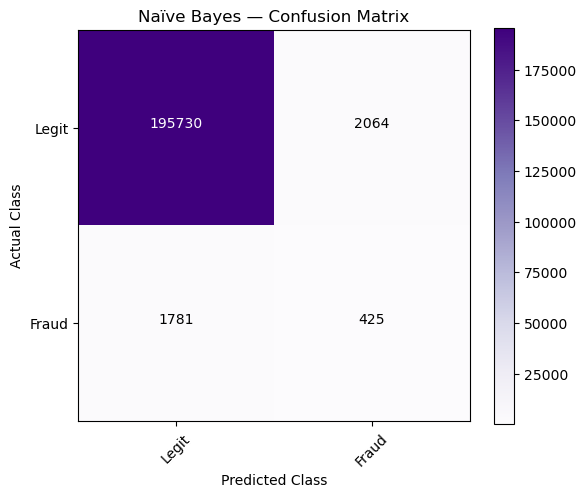


 Naïve Bayes complete.
  Best var_smoothing: 1.00e-07
  Test F1: 0.1810  |  ROC-AUC: 0.8309  |  Recall: 0.1927


In [3]:
# Dataset - Feedzai Bank Account Fraud (999,999 rows, 32 features)
# Target - fraud_bool (1.1% fraud — heavily imbalanced)
# Uses GaussianNB for continuous features

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

# Load Data

key_path = "../../../fraud-detection-key.json"

if os.path.exists(key_path):
    client = bigquery.Client.from_service_account_json(key_path)
    query = "SELECT * FROM `csci-4022.CSCI.fraud_data`"
    print("Fetching dataset...")
    df = client.query(query).to_dataframe()
    print(f"Loaded {len(df):,} rows.")
else:
    raise FileNotFoundError("BigQuery key not found at: " + key_path)

# Preprocessing

sentinel_cols = ["prev_address_months_count", "bank_months_count"]
for col in sentinel_cols:
    df[col] = df[col].replace(-1, np.nan)

y = df["fraud_bool"]
X = df.drop(columns=["fraud_bool"])

print(f"\nFraud rate: {y.mean()*100:.2f}%")
print(f"Dataset shape: {X.shape}")

numeric_cols    = X.select_dtypes(include=["float64", "int64", "Int64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

# Data Transformation

print("\n Data Transformation")

# Fillinmg numeric missing values
X_nb = X.copy()
for col in numeric_cols:
    X_nb[col] = X_nb[col].fillna(X_nb[col].median())

# Encode categorical columns with LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    X_nb[col] = X_nb[col].fillna("unknown")
    X_nb[col] = le.fit_transform(X_nb[col].astype(str))

# Show transformation snapshot
print("Before MinMaxScaling:")
print(f"  income range:            [{df['income'].min():.4f}, {df['income'].max():.4f}]")
print(f"  session_length range:    [{df['session_length_in_minutes'].min():.2f}, {df['session_length_in_minutes'].max():.2f}]")

scaler = MinMaxScaler()
cols_to_scale = ["income", "session_length_in_minutes", "proposed_credit_limit",
                 "days_since_request", "velocity_6h", "velocity_24h", "velocity_4w"]
X_nb[cols_to_scale] = scaler.fit_transform(X_nb[cols_to_scale])

print("After MinMaxScaling:")
print(f"  income range:            [{X_nb['income'].min():.4f}, {X_nb['income'].max():.4f}]")
print(f"  session_length range:    [{X_nb['session_length_in_minutes'].min():.4f}, {X_nb['session_length_in_minutes'].max():.4f}]")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nb, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train fraud: {y_train.sum():,}  |  Test fraud: {y_test.sum():,}")

# Baseline Gaussian Naïve Bayes

print("\n Baseline Gaussian Naive Bayes")
gnb_base = GaussianNB()
gnb_base.fit(X_train, y_train)
y_pred_base = gnb_base.predict(X_test)
y_prob_base = gnb_base.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_base):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_base):.4f}  ← key metric for imbalanced data")

# Hyperparameter Tuning var_smoothing

print("\n Hyperparameter Tuning: var_smoothing")
smoothing_values = np.logspace(-12, 0, 13)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_f1, best_vs, best_model = 0, None, None
for vs in smoothing_values:
    model = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    if scores.mean() > best_f1:
        best_f1 = scores.mean()
        best_vs  = vs
        best_model = model

print(f"Best var_smoothing: {best_vs:.2e}")
print(f"Best CV F1-Score:   {best_f1:.4f}")

# Tuned model evaluation

print("\n Tuned Gaussian Naive Bayes Evaluation")
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_prob)
pr   = average_precision_score(y_test, y_prob)

print(f"Accuracy:  {acc:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc:.4f}")
print(f"PR-AUC:    {pr:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"], digits=4))

# Threshold Tuning
# GaussianNB cannot use class_weight='balanced' directly so we lower the decision threshold from 0.5 to improve recall
# This trades precision for recall reasonable when missing fraud is costly

print("\n Threshold Analysis")
print(f"{'Threshold':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'TP':>8} {'FP':>8}")
print("-" * 62)
for thresh in [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]:
    y_t = (y_prob >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_t)
    p_t  = precision_score(y_test, y_t, zero_division=0)
    r_t  = recall_score(y_test, y_t)
    f1_t = f1_score(y_test, y_t, zero_division=0)
    tp   = cm_t[1, 1]
    fp   = cm_t[0, 1]
    print(f"{thresh:<12.2f} {p_t:>10.4f} {r_t:>10.4f} {f1_t:>10.4f} {tp:>8} {fp:>8}")

# Confusion Matrix Plot

classes = ["Legit", "Fraud"]
mcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Purples)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Naïve Bayes — Confusion Matrix")
thresh = mcm.max() / 2.
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig("david_naive_bayes_confusion_matrix.png", dpi=150)
plt.show()

print("\n Naïve Bayes complete.")
print(f"  Best var_smoothing: {best_vs:.2e}")
print(f"  Test F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}  |  Recall: {rec:.4f}")

Model 3: Apriori / Frequent Pattern Mining

In [4]:
# !pip install mlxtend (if mlxtend unavailable, uses built-in manual Apriori)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from google.cloud import bigquery
from itertools import combinations
from collections import defaultdict

import warnings
warnings.filterwarnings("ignore")

In [5]:
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    USE_MLXTEND = True
    print("Using mlxtend Apriori")
except ImportError:
    USE_MLXTEND = False
    print("mlxtend not found — using manual Apriori implementation")

# Load data

key_path = "../../../fraud-detection-key.json"

if os.path.exists(key_path):
    client = bigquery.Client.from_service_account_json(key_path)
    query = "SELECT * FROM `csci-4022.CSCI.fraud_data`"
    print("Fetching dataset...")
    df = client.query(query).to_dataframe()
    print(f"Loaded {len(df):,} rows.")
else:
    raise FileNotFoundError("BigQuery key not found at: " + key_path)

print("\n Discretizing features for Pattern Mining")

sentinel_cols = ["prev_address_months_count", "bank_months_count"]
for col in sentinel_cols:
    df[col] = df[col].replace(-1, np.nan)

selected_features = [
    "income",
    "credit_risk_score",
    "foreign_request",
    "phone_home_valid",
    "phone_mobile_valid",
    "has_other_cards",
    "email_is_free",
    "keep_alive_session",
    "velocity_6h",
    "velocity_24h",
]

df_ap = df[selected_features + ["fraud_bool"]].copy()

# Fill missing values before binning
df_ap["income"]           = df_ap["income"].fillna(df_ap["income"].median())
df_ap["credit_risk_score"] = df_ap["credit_risk_score"].fillna(df_ap["credit_risk_score"].median())
df_ap["velocity_6h"]      = df_ap["velocity_6h"].fillna(df_ap["velocity_6h"].median())
df_ap["velocity_24h"]     = df_ap["velocity_24h"].fillna(df_ap["velocity_24h"].median())

# Bin continuous features into categories
print("\nBefore discretization:")
print(f"  income range:            [{df_ap['income'].min():.4f}, {df_ap['income'].max():.4f}]")
print(f"  credit_risk_score range: [{df_ap['credit_risk_score'].min()}, {df_ap['credit_risk_score'].max()}]")
print(f"  velocity_6h range:       [{df_ap['velocity_6h'].min():.2f}, {df_ap['velocity_6h'].max():.2f}]")

df_ap["income_bin"]     = pd.qcut(df_ap["income"],     3, labels=["low_inc",  "mid_inc",  "high_inc"])
df_ap["credit_bin"]     = pd.qcut(df_ap["credit_risk_score"], 3, labels=["low_risk", "mid_risk", "high_risk"])
df_ap["velocity6h_bin"] = pd.qcut(df_ap["velocity_6h"].rank(method="first"), 3,
                                   labels=["low_vel6h", "mid_vel6h", "high_vel6h"])
df_ap["velocity24h_bin"]= pd.qcut(df_ap["velocity_24h"].rank(method="first"), 3,
                                   labels=["low_vel24h","mid_vel24h","high_vel24h"])

print("After discretization:")
print(f"  income_bin categories:     {df_ap['income_bin'].unique().tolist()}")
print(f"  credit_bin categories:     {df_ap['credit_bin'].unique().tolist()}")
print(f"  velocity6h_bin categories: {df_ap['velocity6h_bin'].unique().tolist()}")

# Binary/categorical features — keep as-is (already 0/1 or small categories)
binary_features = ["foreign_request", "phone_home_valid", "phone_mobile_valid",
                   "has_other_cards", "email_is_free", "keep_alive_session"]

# Build final item columns
item_cols = ["income_bin", "credit_bin", "velocity6h_bin", "velocity24h_bin"] + binary_features
df_ap = df_ap[item_cols + ["fraud_bool"]].copy()

# Add fraud label as an item
df_ap["fraud_label"] = df_ap["fraud_bool"].map({1: "IS_FRAUD", 0: "IS_LEGIT"})

print(f"\nFraud transactions: {(df_ap['fraud_bool']==1).sum():,}")
print(f"Legit transactions: {(df_ap['fraud_bool']==0).sum():,}")

# Apriori - fraud class only
# Mining within the fraud class reveals fraud-specific signatures
# We compare to legit patterns to find what's exclusive to fraud

df_fraud = df_ap[df_ap["fraud_bool"] == 1][item_cols].copy()
df_legit = df_ap[df_ap["fraud_bool"] == 0][item_cols].copy().sample(n=min(50000, (df_ap["fraud_bool"]==0).sum()), random_state=42)

print(f"\nMining fraud subset ({len(df_fraud):,} rows)...")
print(f"Mining legit sample ({len(df_legit):,} rows) for comparison...")

def run_mlxtend_apriori(dataframe, min_support, label):
    """Use mlxtend apriori on a one-hot encoded dataframe."""
    # One-hot encode all item columns
    encoded = pd.get_dummies(dataframe.astype(str), prefix_sep="=")
    encoded = encoded.astype(bool)
    frequent = apriori(encoded, min_support=min_support, use_colnames=True, max_len=3)
    if frequent.empty:
        print(f"  [{label}] No frequent itemsets at min_support={min_support}")
        return pd.DataFrame(), pd.DataFrame()
    rules = association_rules(frequent, metric="lift", min_threshold=1.2)
    return frequent, rules


# Manual Apriori (fallback)
def get_frequent_manual(transactions, min_support):
    n = len(transactions)
    min_count = min_support * n
    item_counts = defaultdict(int)
    for t in transactions:
        for item in t:
            item_counts[frozenset([item])] += 1
    frequent = {k: v for k, v in item_counts.items() if v >= min_count}
    all_freq = dict(frequent)
    current = list(frequent.keys())
    k = 2
    while current:
        items = sorted({i for fs in current for i in fs})
        cands = {frozenset(c) for c in combinations(items, k)}
        counts = defaultdict(int)
        for t in transactions:
            ts = set(t)
            for c in cands:
                if c.issubset(ts):
                    counts[c] += 1
        freq_k = {k2: v for k2, v in counts.items() if v >= min_count}
        if not freq_k:
            break
        all_freq.update(freq_k)
        current = list(freq_k.keys())
        k += 1
    return all_freq, n


def get_rules_manual(frequent_itemsets, n, min_conf=0.5, min_lift=1.2):
    rules = []
    for itemset, count in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        support = count / n
        for i in range(1, len(itemset)):
            for ant in combinations(sorted(itemset), i):
                ant = frozenset(ant)
                con = itemset - ant
                ant_c = frequent_itemsets.get(ant, 0)
                con_c = frequent_itemsets.get(con, 0)
                if ant_c == 0 or con_c == 0:
                    continue
                conf = count / ant_c
                lift = conf / (con_c / n)
                if conf >= min_conf and lift >= min_lift:
                    rules.append({
                        "antecedents": set(ant),
                        "consequents": set(con),
                        "support":    round(support, 6),
                        "confidence": round(conf, 4),
                        "lift":       round(lift, 4),
                    })
    return sorted(rules, key=lambda x: x["lift"], reverse=True)


MIN_SUPPORT    = 0.15   # 15% of the fraud class (lower than typical because fraud class is small)
MIN_CONFIDENCE = 0.50
MIN_LIFT       = 1.2

print(f"\nApriori thresholds: support≥{MIN_SUPPORT}, confidence≥{MIN_CONFIDENCE}, lift≥{MIN_LIFT}")
print("Note: Thresholds relative to each class subset, not full dataset")

if USE_MLXTEND:
    print("\n[mlxtend] Mining fraud patterns...")
    freq_fraud, rules_fraud = run_mlxtend_apriori(df_fraud, MIN_SUPPORT, "FRAUD")
    print(f"  Frequent itemsets (fraud): {len(freq_fraud)}")
    print(f"  Association rules (fraud): {len(rules_fraud)}")

    print("\n[mlxtend] Mining legit patterns...")
    freq_legit, rules_legit = run_mlxtend_apriori(df_legit, MIN_SUPPORT, "LEGIT")
    print(f"  Frequent itemsets (legit): {len(freq_legit)}")

    print("\nTop Fraud Rules (by lift)")
    if not rules_fraud.empty:
        top_rules = rules_fraud.sort_values("lift", ascending=False).head(15)
        print(top_rules[["antecedents", "consequents", "support", "confidence", "lift"]].to_string(index=False))
    else:
        print("No rules found — try lowering min_support")

else:
    # Manual fallback
    def df_to_transactions(dataframe):
        return [
            [f"{col}={row[col]}" for col in dataframe.columns if pd.notna(row[col])]
            for _, row in dataframe.iterrows()
        ]

    print("\n[manual] Converting to transaction format...")
    fraud_transactions = df_to_transactions(df_fraud)
    legit_transactions = df_to_transactions(df_legit)

    print("[manual] Mining fraud patterns...")
    freq_fraud, n_fraud = get_frequent_manual(fraud_transactions, MIN_SUPPORT)
    print(f"  Frequent itemsets (fraud): {len(freq_fraud)}")

    rules_fraud = get_rules_manual(freq_fraud, n_fraud, MIN_CONFIDENCE, MIN_LIFT)
    print(f"  Rules generated (fraud):   {len(rules_fraud)}")

    print("\n[manual] Mining legit patterns...")
    freq_legit, n_legit = get_frequent_manual(legit_transactions, MIN_SUPPORT)
    print(f"  Frequent itemsets (legit): {len(freq_legit)}")

    print("\n Top 15 Fraud Rules (by lift)")
    print(f"{'Antecedent':<45} {'Consequent':<25} {'Supp':>6} {'Conf':>6} {'Lift':>6}")
    print("-" * 92)
    for rule in rules_fraud[:15]:
        ant = ", ".join(sorted(rule["antecedents"]))[:43]
        con = ", ".join(sorted(rule["consequents"]))[:23]
        print(f"{ant:<45} {con:<25} {rule['support']:>6.4f} {rule['confidence']:>6.4f} {rule['lift']:>6.4f}")

# Comparing fraud vs legit rules

print("\n Fraud vs Legit Pattern Comparison ")
print("This identifies which patterns are fraud-exclusive")
print("(appear frequently in fraud transactions but not legit)")

if USE_MLXTEND and not freq_fraud.empty and not freq_legit.empty:
    fraud_items = set()
    for itemset in freq_fraud["itemsets"]:
        for item in itemset:
            fraud_items.add(item)
    legit_items = set()
    for itemset in freq_legit["itemsets"]:
        for item in itemset:
            legit_items.add(item)
    exclusive = fraud_items - legit_items
    print(f"\nItems frequent in fraud but not legit: {sorted(exclusive)}")
elif not USE_MLXTEND:
    fraud_items = {item for fs in freq_fraud for item in fs}
    legit_items = {item for fs in freq_legit for item in fs}
    exclusive = fraud_items - legit_items
    print(f"\nItems frequent in fraud but not legit: {sorted(exclusive)}")

# Full dataset mlxtend path

print("\n Apriori on mixed sample (with fraud_label item)")
print("(fraud_bool included as an item in transactions)")

sample_size = 5000
df_sample = df_ap.sample(n=sample_size, random_state=42)

if USE_MLXTEND:
    # Include fraud_label as a column item
    sample_cols = item_cols + ["fraud_label"]
    encoded_sample = pd.get_dummies(df_sample[sample_cols].astype(str), prefix_sep="=")
    encoded_sample = encoded_sample.astype(bool)

    freq_sample = apriori(encoded_sample, min_support=0.01, use_colnames=True, max_len=3)
    if not freq_sample.empty:
        rules_sample = association_rules(freq_sample, metric="lift", min_threshold=1.2)
        fraud_rules = rules_sample[
            rules_sample["consequents"].apply(lambda x: any("IS_FRAUD" in str(i) for i in x))
        ]
        print(f"\nFraud-targeted rules found: {len(fraud_rules)}")
        print("\nTop 10 Fraud Rules:")
        print(fraud_rules.sort_values("lift", ascending=False).head(10)[
            ["antecedents", "consequents", "support", "confidence", "lift"]
        ].to_string(index=False))
    else:
        print("No frequent itemsets found at min_support=0.01")

# Metrics summary table

print("\nPattern Mining Evaluation Metrics")
print(f"{'Metric':<20} {'Value':<20} {'Description'}")
print("-" * 70)
print(f"{'min_support':<20} {MIN_SUPPORT:<20.2f} {'Min fraction of class containing itemset'}")
print(f"{'min_confidence':<20} {MIN_CONFIDENCE:<20.2f} {'Min P(consequent | antecedent)'}")
print(f"{'min_lift':<20} {MIN_LIFT:<20.2f} {'Min ratio vs random — >1 means useful rule'}")
if USE_MLXTEND:
    if not rules_fraud.empty:
        best = rules_fraud.sort_values("lift", ascending=False).iloc[0]
        print(f"\nBest rule lift:       {best['lift']:.4f}")
        print(f"Best rule confidence: {best['confidence']:.4f}")
        print(f"Best rule support:    {best['support']:.4f}")
elif rules_fraud:
    print(f"\nBest rule lift:       {rules_fraud[0]['lift']:.4f}")
    print(f"Best rule confidence: {rules_fraud[0]['confidence']:.4f}")
    print(f"Best rule support:    {rules_fraud[0]['support']:.4f}")

print("\n Apriori / Pattern Mining complete.")

mlxtend not found — using manual Apriori implementation
Fetching dataset...
Loaded 999,999 rows.

 Discretizing features for Pattern Mining

Before discretization:
  income range:            [0.1000, 0.9000]
  credit_risk_score range: [-170, 389]
  velocity_6h range:       [-170.60, 16715.57]
After discretization:
  income_bin categories:     ['low_inc', 'high_inc', 'mid_inc']
  credit_bin categories:     ['high_risk', 'mid_risk', 'low_risk']
  velocity6h_bin categories: ['mid_vel6h', 'high_vel6h', 'low_vel6h']

Fraud transactions: 11,029
Legit transactions: 988,970

Mining fraud subset (11,029 rows)...
Mining legit sample (50,000 rows) for comparison...

Apriori thresholds: support≥0.15, confidence≥0.5, lift≥1.2
Note: Thresholds relative to each class subset, not full dataset

[manual] Converting to transaction format...
[manual] Mining fraud patterns...
  Frequent itemsets (fraud): 687
  Rules generated (fraud):   105

[manual] Mining legit patterns...
  Frequent itemsets (legit): 46

## Model 4: Logistic Regression

In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

Fetching dataset...
Loaded 999,999 rows.

Fraud rate: 1.10%
Dataset shape: (999999, 31)

Train: 799,999  |  Test: 200,000
Train fraud: 8,823  |  Test fraud: 2,206

 Data Transformation Snapshot
Before StandardScaler (sample values from first row):
  income:              0.1000
  velocity_6h:         8892.0079
  proposed_credit_limit: 200.00
After StandardScaler (mean=0, std=1):
  income:              -1.5942
  velocity_6h:         1.0717

Processed train shape: (799999, 51)
Processed test shape:  (200000, 51)

 Baseline Logistic Regression
Accuracy:  0.7909
Recall:    0.7239
Precision: 0.0373
F1-Score:  0.0710
ROC-AUC:   0.8175

Hyperparameter Tuning (GridSearchCV, 5-fold Stratified CV)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
Best CV F1:  0.0776

 Tuned Logistic Regression Evaluation
Accuracy:  0.8065
Recall:    0.7874
Precision: 0.0435
F1-Score:  0.0824
ROC-AUC:   0.8763
PR-AUC:    0.1292  ← most informa

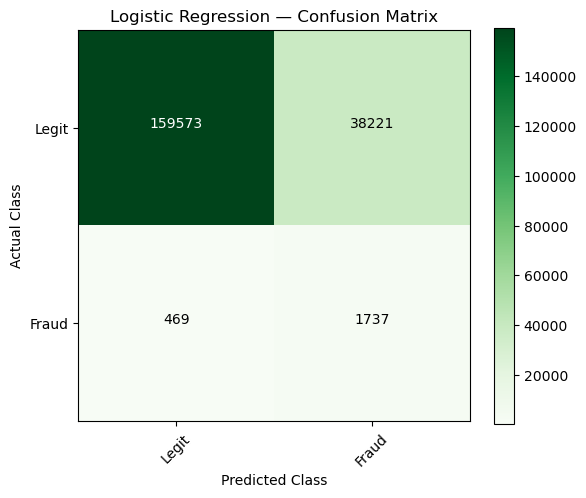

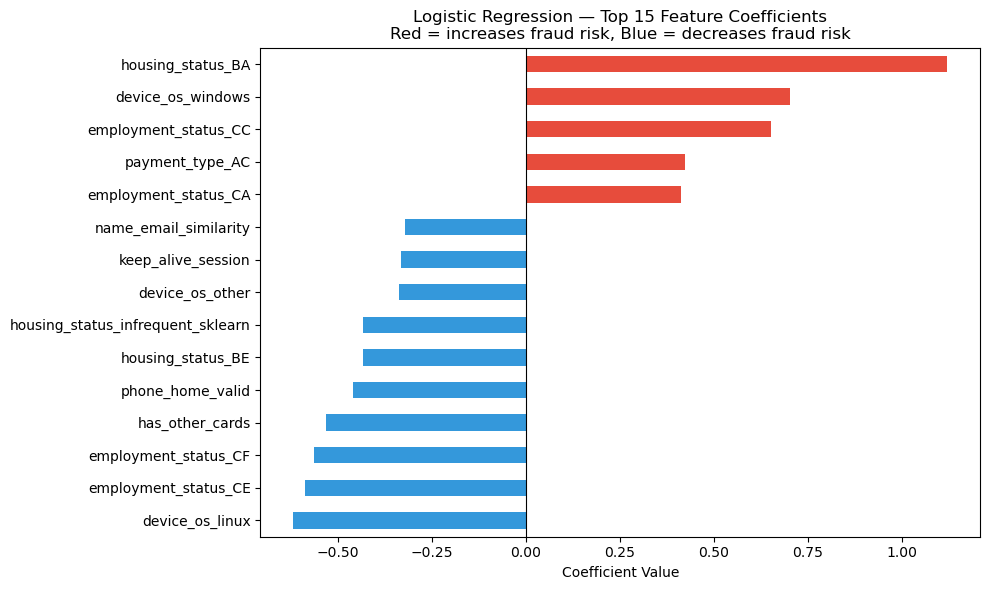


 Logistic Regression complete
  Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
  Test F1: 0.0824  |  ROC-AUC: 0.8763  |  Recall: 0.7874

  Saved: david_lr_model.pkl, david_preprocessor.pkl


In [7]:
# Load data

key_path = "../../../fraud-detection-key.json"

if os.path.exists(key_path):
    client = bigquery.Client.from_service_account_json(key_path)
    query = "SELECT * FROM `csci-4022.CSCI.fraud_data`"
    print("Fetching dataset...")
    df = client.query(query).to_dataframe()
    print(f"Loaded {len(df):,} rows.")
else:
    raise FileNotFoundError("BigQuery key not found at: " + key_path)

# Preprocessing

sentinel_cols = ["prev_address_months_count", "bank_months_count"]
for col in sentinel_cols:
    df[col] = df[col].replace(-1, np.nan)

y = df["fraud_bool"]
X = df.drop(columns=["fraud_bool"])

print(f"\nFraud rate: {y.mean()*100:.2f}%")
print(f"Dataset shape: {X.shape}")

numeric_cols     = X.select_dtypes(include=["float64", "int64", "Int64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())          # LR requires scaling — critical
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist",
                               min_frequency=0.01, sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train fraud: {y_train.sum():,}  |  Test fraud: {y_test.sum():,}")

# Transformation snapshot
print("\n Data Transformation Snapshot")
print("Before StandardScaler (sample values from first row):")
print(f"  income:              {X_train['income'].iloc[0]:.4f}")
print(f"  velocity_6h:         {X_train['velocity_6h'].iloc[0]:.4f}")
print(f"  proposed_credit_limit: {X_train['proposed_credit_limit'].iloc[0]:.2f}")

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Show scaled values (numeric cols come first in ColumnTransformer output)
income_idx = numeric_cols.index("income")
vel_idx    = numeric_cols.index("velocity_6h")
print("After StandardScaler (mean=0, std=1):")
print(f"  income:              {X_train_proc[0, income_idx]:.4f}")
print(f"  velocity_6h:         {X_train_proc[0, vel_idx]:.4f}")
print(f"\nProcessed train shape: {X_train_proc.shape}")
print(f"Processed test shape:  {X_test_proc.shape}")

# Baseline Model

print("\n Baseline Logistic Regression")
baseline_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="saga"        # saga handles large datasets and supports L1
)
baseline_lr.fit(X_train_proc, y_train)
y_pred_base = baseline_lr.predict(X_test_proc)
y_prob_base = baseline_lr.predict_proba(X_test_proc)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_base):.4f}")

# Hyperparameter Tuning

print("\nHyperparameter Tuning (GridSearchCV, 5-fold Stratified CV)")

param_grid = [
    {
        "C":       [0.001, 0.01, 0.1, 1, 10],
        "penalty": ["l2"],
        "solver":  ["saga"],
    },
    {
        "C":       [0.001, 0.01, 0.1, 1, 10],
        "penalty": ["l1"],
        "solver":  ["saga"],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_proc, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV F1:  {grid_search.best_score_:.4f}")

# Tuned Model Evaluation

print("\n Tuned Logistic Regression Evaluation")
best_lr = grid_search.best_estimator_
y_pred  = best_lr.predict(X_test_proc)
y_prob  = best_lr.predict_proba(X_test_proc)[:, 1]

acc  = accuracy_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_prob)
pr   = average_precision_score(y_test, y_prob)

print(f"Accuracy:  {acc:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc:.4f}")
print(f"PR-AUC:    {pr:.4f}  ← most informative for imbalanced data")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"], digits=4))

# Threshold Analysis
# Default threshold = 0.5 is biased toward legit when fraud is only 1.1% - lowering the threshold catches more fraud (higher recall) at the cost of more false alarms (lower precision) - tradeoff documented

print("\n Threshold Analysis")
print(f"{'Threshold':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'TP':>8} {'FP':>8}")
print("-" * 62)
for thresh in [0.5, 0.3, 0.2, 0.1, 0.05]:
    y_t  = (y_prob >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_t)
    p_t  = precision_score(y_test, y_t, zero_division=0)
    r_t  = recall_score(y_test, y_t)
    f1_t = f1_score(y_test, y_t, zero_division=0)
    print(f"{thresh:<12.2f} {p_t:>10.4f} {r_t:>10.4f} {f1_t:>10.4f} "
          f"{cm_t[1,1]:>8} {cm_t[0,1]:>8}")

# Feature Coefficients

cat_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_cols)
all_names = list(numeric_cols) + list(cat_names)

coefs = pd.Series(best_lr.coef_[0], index=all_names)
top_positive = coefs.sort_values(ascending=False).head(10)
top_negative = coefs.sort_values(ascending=True).head(10)

print("\nTop 10 features INCREASING fraud risk (positive coefficients):")
for feat, coef in top_positive.items():
    print(f"  {feat:<45} +{coef:.4f}")

print("\nTop 10 features DECREASING fraud risk (negative coefficients):")
for feat, coef in top_negative.items():
    print(f"  {feat:<45}  {coef:.4f}")

# Plots

# Confusion matrix
classes = ["Legit", "Fraud"]
mcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Greens)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Logistic Regression — Confusion Matrix")
thresh_plot = mcm.max() / 2.
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh_plot else "black")
plt.tight_layout()
plt.savefig("david_logistic_regression_confusion_matrix.png", dpi=150)
plt.show()

# Coefficient plot
plt.figure(figsize=(10, 6))
top_abs = coefs.abs().sort_values(ascending=False).head(15)
top_coef = coefs[top_abs.index].sort_values()
colors = ["#e74c3c" if v > 0 else "#3498db" for v in top_coef]
top_coef.plot(kind="barh", color=colors)
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression — Top 15 Feature Coefficients\nRed = increases fraud risk, Blue = decreases fraud risk")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("david_logistic_regression_coefficients.png", dpi=150)
plt.show()

print("\n Logistic Regression complete")
print(f"  Best params: {grid_search.best_params_}")
print(f"  Test F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}  |  Recall: {rec:.4f}")

# Export fitted objects for use in the stacking script
import joblib
joblib.dump(best_lr,       "david_lr_model.pkl")
joblib.dump(preprocessor,  "david_preprocessor.pkl")
print("\n  Saved: david_lr_model.pkl, david_preprocessor.pkl")

## Model 5: Ensemble (Voting + Stacking)

In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    recall_score, precision_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings("ignore")

Fetching dataset...
Loaded 999,999 rows.

Train: 799,999  |  Test: 200,000
Fraud rate — Train: 1.10%  |  Test: 1.10%
Processed shape: (799999, 51)

 Class Imbalance
After resampling: {np.int64(0): 8823, np.int64(1): 8823}
Resampled train shape: (17646, 51)
KNN training sample: 3,529 rows

 Defining base models

 Training base models

  Full balanced training set:
  Decision Tree          Acc=0.7498  Rec=0.7294  Prec=0.0315  F1=0.0604  ROC=0.8040
  Naïve Bayes            Acc=0.6976  Rec=0.8132  Prec=0.0290  F1=0.0560  ROC=0.8239
  Logistic Regression    Acc=0.8043  Rec=0.7865  Prec=0.0429  F1=0.0814  ROC=0.8767
  Linear SVC (Sawyer)    Acc=0.8043  Rec=0.7874  Prec=0.0430  F1=0.0815  ROC=0.8765
  Random Forest (Sam)    Acc=0.8113  Rec=0.7838  Prec=0.0443  F1=0.0839  ROC=0.8805
  Grad Boosting (Sam)    Acc=0.8197  Rec=0.8114  Prec=0.0478  F1=0.0903  ROC=0.8953

  KNN sample (20% of balanced set):


  File "c:\Users\savic\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\savic\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\savic\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\savic\anaconda3\Lib\subprocess.

  KNN                    Acc=0.6938  Rec=0.7897  Prec=0.0279  F1=0.0538  ROC=0.8064

  RBF SVM sample (20% of balanced set — expensive):
  RBF SVM                Acc=0.7881  Rec=0.8042  Prec=0.0406  F1=0.0773  ROC=0.8730

ENSEMBLE 1: SOFT VOTING CLASSIFIER
All models vote using their fraud probability.
Final label = argmax(mean probabilities across models).

Fitting Soft Voting Classifier...

Soft Voting Results:
  Accuracy:  0.7948
  Recall:    0.8137
  Precision: 0.0423
  F1-Score:  0.0804
  ROC-AUC:   0.8846

Confusion Matrix:
[[157160  40634]
 [   411   1795]]

Classification Report:
              precision    recall  f1-score   support

       Legit     0.9974    0.7946    0.8845    197794
       Fraud     0.0423    0.8137    0.0804      2206

    accuracy                         0.7948    200000
   macro avg     0.5198    0.8041    0.4825    200000
weighted avg     0.9869    0.7948    0.8756    200000


ENSEMBLE 2: STACKING CLASSIFIER
Base models generate fold predictions → LR me

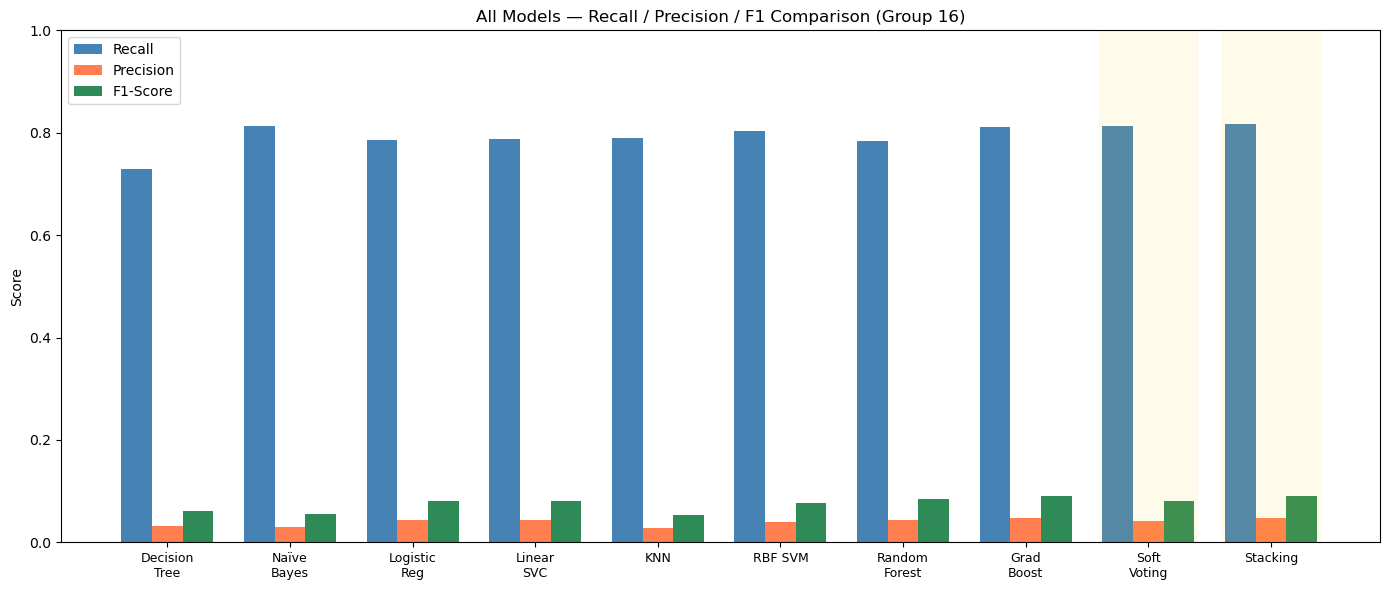

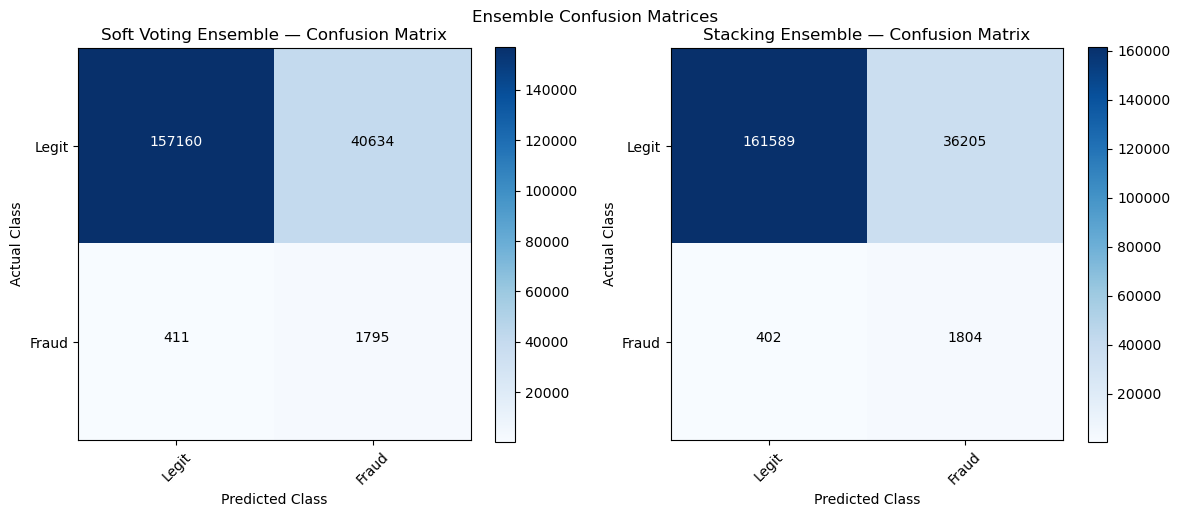


 Ensemble Analysis
Soft Voting benefits:
  + Averages out individual model errors
  + High-confidence models (RF, GB) naturally dominate the vote
  + No extra training required beyond individual models
  + Recall improves because at least one model catches fraud the others miss

Stacking benefits:
  + Meta-learner LEARNS which base models to trust for which cases
  + Out-of-fold predictions prevent data leakage from base → meta level
  + Can outperform voting when base models have very different error profiles
  + LR meta-learner with class_weight='balanced' keeps fraud focus

Challenges:
  Challenge: KNN and RBF SVM are too slow to train on 800k balanced rows
  Solution:  Both trained on 20% stratified subsample

  Challenge: GaussianNB assumes independence — may hurt ensemble calibration
  Solution:  Soft voting uses probabilities; NB's contribution is down-weighted
             naturally when its predictions diverge from the majority

  Challenge: Stacking CV=5 is slow on large bal

In [9]:
# Load data

key_path = "../../../fraud-detection-key.json"

if os.path.exists(key_path):
    client = bigquery.Client.from_service_account_json(key_path)
    query = "SELECT * FROM `csci-4022.CSCI.fraud_data`"
    print("Fetching dataset...")
    df = client.query(query).to_dataframe()
    print(f"Loaded {len(df):,} rows.")
else:
    raise FileNotFoundError("BigQuery key not found at: " + key_path)

# Preprocessing

sentinel_cols = ["prev_address_months_count", "bank_months_count"]
for col in sentinel_cols:
    df[col] = df[col].replace(-1, np.nan)

y = df["fraud_bool"]
X = df.drop(columns=["fraud_bool"])

numeric_cols     = X.select_dtypes(include=["float64", "int64", "Int64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

# Shared preprocessor 
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist",
                               min_frequency=0.01, sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Fraud rate — Train: {y_train.mean()*100:.2f}%  |  Test: {y_test.mean()*100:.2f}%")

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print(f"Processed shape: {X_train_proc.shape}")

# Class imbalance handling

print("\n Class Imbalance")
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train_proc, y_train)
print(f"After resampling: {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Resampled train shape: {X_train_bal.shape}")

# For KNN (expensive) use a 20% sample of the balanced set
np.random.seed(42)
knn_sample_size = int(0.2 * X_train_bal.shape[0])
knn_idx = np.random.choice(X_train_bal.shape[0], size=knn_sample_size, replace=False)
X_knn_train = X_train_bal[knn_idx]
y_knn_train = y_train_bal.iloc[knn_idx] if hasattr(y_train_bal, "iloc") else y_train_bal[knn_idx]
print(f"KNN training sample: {X_knn_train.shape[0]:,} rows")

# Define base models

print("\n Defining base models")

dt = DecisionTreeClassifier(
    max_depth=12, min_samples_leaf=10,
    class_weight="balanced", random_state=42
)

nb = GaussianNB(var_smoothing=1e-9)

lr = LogisticRegression(
    C=0.1, penalty="l2", solver="saga",
    class_weight="balanced", max_iter=1000, random_state=42
)

# LinearSVC wrapped in CalibratedClassifierCV for probability output
linear_svc_base = LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=5000)
calibrated_svc  = CalibratedClassifierCV(linear_svc_base, cv=3)

# RBF SVM — expensive, train on balanced subset
rbf_svm = SVC(
    kernel="rbf", class_weight="balanced",
    probability=True, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight="balanced", random_state=42, n_jobs=-1
)

gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=3, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

# Train base models individually
# Train each and record baseline metrics before ensembling

print("\n Training base models")

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    prob  = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    rec   = recall_score(y_te, pred)
    prec  = precision_score(y_te, pred, zero_division=0)
    f1    = f1_score(y_te, pred, zero_division=0)
    acc   = accuracy_score(y_te, pred)
    roc   = roc_auc_score(y_te, prob) if prob is not None else float("nan")
    print(f"  {name:<22} Acc={acc:.4f}  Rec={rec:.4f}  Prec={prec:.4f}  F1={f1:.4f}  ROC={roc:.4f}")
    return model, pred, prob

results = {}

print("\n  Full balanced training set:")
results["Decision Tree"], _, _   = evaluate("Decision Tree",       dt,           X_train_bal, y_train_bal, X_test_proc, y_test)
results["Naïve Bayes"],   _, _   = evaluate("Naïve Bayes",         nb,           X_train_bal, y_train_bal, X_test_proc, y_test)
results["Logistic Reg"],  _, _   = evaluate("Logistic Regression", lr,           X_train_bal, y_train_bal, X_test_proc, y_test)
results["Linear SVC"],    _, _   = evaluate("Linear SVC (Sawyer)", calibrated_svc, X_train_bal, y_train_bal, X_test_proc, y_test)
results["Random Forest"], _, _   = evaluate("Random Forest (Sam)", rf,           X_train_bal, y_train_bal, X_test_proc, y_test)
results["Grad Boosting"], _, _   = evaluate("Grad Boosting (Sam)", gb,           X_train_bal, y_train_bal, X_test_proc, y_test)

print("\n  KNN sample (20% of balanced set):")
results["KNN"], _, _ = evaluate("KNN", knn, X_knn_train, y_knn_train, X_test_proc, y_test)

print("\n  RBF SVM sample (20% of balanced set — expensive):")
results["RBF SVM"], _, _ = evaluate("RBF SVM", rbf_svm, X_knn_train, y_knn_train, X_test_proc, y_test)

# Ensemble 1 - Soft Voting

# Each model votes with its fraud probability
# The final prediction is the class with the highest average probability
# Better than hard voting because it captures model confidence

print("\n" + "="*60)
print("ENSEMBLE 1: SOFT VOTING CLASSIFIER")
print("="*60)
print("All models vote using their fraud probability.")
print("Final label = argmax(mean probabilities across models).")

voting_clf = VotingClassifier(
    estimators=[
        ("dt",   dt),
        ("nb",   nb),
        ("lr",   lr),
        ("svc",  calibrated_svc),
        ("rf",   rf),
        ("gb",   gb),
        ("knn",  knn),
        ("svm",  rbf_svm),
    ],
    voting="soft",
    n_jobs=-1
)

# Re-fit all base models inside the VotingClassifier
# KNN and RBF SVM are passed with their fitted state from above
# but VotingClassifier re-fits them — use sample for expensive models
# by fitting the voting clf on the balanced full set
print("\nFitting Soft Voting Classifier...")
voting_clf.fit(X_train_bal, y_train_bal)

voting_pred = voting_clf.predict(X_test_proc)
voting_prob = voting_clf.predict_proba(X_test_proc)[:, 1]

v_acc  = accuracy_score(y_test, voting_pred)
v_rec  = recall_score(y_test, voting_pred)
v_prec = precision_score(y_test, voting_pred, zero_division=0)
v_f1   = f1_score(y_test, voting_pred, zero_division=0)
v_roc  = roc_auc_score(y_test, voting_prob)

print(f"\nSoft Voting Results:")
print(f"  Accuracy:  {v_acc:.4f}")
print(f"  Recall:    {v_rec:.4f}")
print(f"  Precision: {v_prec:.4f}")
print(f"  F1-Score:  {v_f1:.4f}")
print(f"  ROC-AUC:   {v_roc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, voting_pred))
print("\nClassification Report:")
print(classification_report(y_test, voting_pred, target_names=["Legit", "Fraud"], digits=4))

# Ensebmle 2 - Stacking

print("\n" + "="*60)
print("ENSEMBLE 2: STACKING CLASSIFIER")
print("="*60)
print("Base models generate fold predictions → LR meta-learner combines them.")
print("Meta-learner: Logistic Regression with class_weight='balanced'")

stacking_clf = StackingClassifier(
    estimators=[
        ("dt",   dt),
        ("nb",   nb),
        ("lr",   lr),
        ("svc",  calibrated_svc),
        ("rf",   rf),
        ("gb",   gb),
        ("knn",  knn),
        ("svm",  rbf_svm),
    ],
    final_estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    cv=5,               # 5-fold cross-val for out-of-fold predictions
    passthrough=False,  # meta-learner only sees base model outputs
    n_jobs=-1
)

print("\nFitting Stacking Classifier (5-fold CV — this takes a few minutes)...")
stacking_clf.fit(X_train_bal, y_train_bal)

stacking_pred = stacking_clf.predict(X_test_proc)
stacking_prob = stacking_clf.predict_proba(X_test_proc)[:, 1]

s_acc  = accuracy_score(y_test, stacking_pred)
s_rec  = recall_score(y_test, stacking_pred)
s_prec = precision_score(y_test, stacking_pred, zero_division=0)
s_f1   = f1_score(y_test, stacking_pred, zero_division=0)
s_roc  = roc_auc_score(y_test, stacking_prob)

print(f"\nStacking Results:")
print(f"  Accuracy:  {s_acc:.4f}")
print(f"  Recall:    {s_rec:.4f}")
print(f"  Precision: {s_prec:.4f}")
print(f"  F1-Score:  {s_f1:.4f}")
print(f"  ROC-AUC:   {s_roc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, stacking_pred))
print("\nClassification Report:")
print(classification_report(y_test, stacking_pred, target_names=["Legit", "Fraud"], digits=4))

# Full comparison table

print("\n" + "="*70)
print("FULL MODEL COMPARISON")
print("="*70)

# Collect all individual results
individual_models = {
    "Decision Tree (David)": results["Decision Tree"],
    "Naïve Bayes (David)": results["Naïve Bayes"],
    "Logistic Reg (David)": results["Logistic Reg"],
    "Linear SVC (Sawyer)": results["Linear SVC"],
    "KNN (Sawyer)": results["KNN"],
    "RBF SVM (Sam)": results["RBF SVM"],
    "Random Forest (Sam)": results["Random Forest"],
    "Grad Boosting (Sam)": results["Grad Boosting"],
}

header = f"  {'Model':<28} {'Accuracy':>9} {'Recall':>9} {'Precision':>10} {'F1':>9} {'ROC-AUC':>9}"
print(header)
print("  " + "-" * (len(header) - 2))

for name, model in individual_models.items():
    pred = model.predict(X_test_proc)
    prob = model.predict_proba(X_test_proc)[:, 1] if hasattr(model, "predict_proba") else None
    print(
        f"  {name:<28} "
        f"{accuracy_score(y_test, pred):>9.4f} "
        f"{recall_score(y_test, pred):>9.4f} "
        f"{precision_score(y_test, pred, zero_division=0):>10.4f} "
        f"{f1_score(y_test, pred, zero_division=0):>9.4f} "
        f"{roc_auc_score(y_test, prob) if prob is not None else 'N/A':>9}"
    )

print("  " + "-" * (len(header) - 2))
print(
    f"  {'Soft Voting (ALL)':<28} "
    f"{v_acc:>9.4f} {v_rec:>9.4f} {v_prec:>10.4f} {v_f1:>9.4f} {v_roc:>9.4f}"
)
print(
    f"  {'Stacking (ALL)':<28} "
    f"{s_acc:>9.4f} {s_rec:>9.4f} {s_prec:>10.4f} {s_f1:>9.4f} {s_roc:>9.4f}"
)

# Comparison bar chart

model_names = [
    "Decision\nTree", "Naïve\nBayes", "Logistic\nReg",
    "Linear\nSVC", "KNN",
    "RBF SVM", "Random\nForest", "Grad\nBoost",
    "Soft\nVoting", "Stacking"
]

all_preds = [
    dt.predict(X_test_proc),
    nb.predict(X_test_proc),
    lr.predict(X_test_proc),
    calibrated_svc.predict(X_test_proc),
    knn.predict(X_test_proc),
    rbf_svm.predict(X_test_proc),
    rf.predict(X_test_proc),
    gb.predict(X_test_proc),
    voting_pred,
    stacking_pred,
]

recalls    = [recall_score(y_test, p) for p in all_preds]
precisions = [precision_score(y_test, p, zero_division=0) for p in all_preds]
f1s        = [f1_score(y_test, p, zero_division=0) for p in all_preds]

x     = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, recalls,    width, label="Recall",    color="steelblue")
bars2 = ax.bar(x,         precisions, width, label="Precision", color="coral")
bars3 = ax.bar(x + width, f1s,        width, label="F1-Score",  color="seagreen")

ax.set_ylabel("Score")
ax.set_title("All Models — Recall / Precision / F1 Comparison (Group 16)")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.legend()
ax.set_ylim(0, 1)

# Highlight ensemble columns
for i in [8, 9]:   # Soft Voting and Stacking
    ax.axvspan(x[i] - width*1.6, x[i] + width*1.6, alpha=0.08, color="gold")

plt.tight_layout()
plt.savefig("david_ensemble_comparison.png", dpi=150)
plt.show()

# C# Confusion matrix plots - both ensembles


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
classes = ["Legit", "Fraud"]

for ax_sub, pred, title in [
    (axes[0], voting_pred,   "Soft Voting Ensemble"),
    (axes[1], stacking_pred, "Stacking Ensemble"),
]:
    mcm = confusion_matrix(y_test, pred)
    im = ax_sub.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax_sub)
    tick_marks = np.arange(len(classes))
    ax_sub.set_xticks(tick_marks); ax_sub.set_xticklabels(classes, rotation=45)
    ax_sub.set_yticks(tick_marks); ax_sub.set_yticklabels(classes)
    ax_sub.set_xlabel("Predicted Class")
    ax_sub.set_ylabel("Actual Class")
    ax_sub.set_title(f"{title} — Confusion Matrix")
    thresh = mcm.max() / 2.
    for i in range(mcm.shape[0]):
        for j in range(mcm.shape[1]):
            ax_sub.text(j, i, format(mcm[i, j], 'd'),
                        ha="center",
                        color="white" if mcm[i, j] > thresh else "black")

plt.suptitle("Ensemble Confusion Matrices", fontsize=12)
plt.tight_layout()
plt.savefig("david_ensemble_confusion_matrices.png", dpi=150)
plt.show()

# Ensemble analysis 
print("\n Ensemble Analysis")
print("Soft Voting benefits:")
print("  + Averages out individual model errors")
print("  + High-confidence models (RF, GB) naturally dominate the vote")
print("  + No extra training required beyond individual models")
print("  + Recall improves because at least one model catches fraud the others miss")

print("\nStacking benefits:")
print("  + Meta-learner LEARNS which base models to trust for which cases")
print("  + Out-of-fold predictions prevent data leakage from base → meta level")
print("  + Can outperform voting when base models have very different error profiles")
print("  + LR meta-learner with class_weight='balanced' keeps fraud focus")

print("\nChallenges:")
print("  Challenge: KNN and RBF SVM are too slow to train on 800k balanced rows")
print("  Solution:  Both trained on 20% stratified subsample")
print("")
print("  Challenge: GaussianNB assumes independence — may hurt ensemble calibration")
print("  Solution:  Soft voting uses probabilities; NB's contribution is down-weighted")
print("             naturally when its predictions diverge from the majority")
print("")
print("  Challenge: Stacking CV=5 is slow on large balanced dataset")
print("  Solution:  All base models share the same preprocessor output (no re-processing)")
print("             and n_jobs=-1 parallelizes across folds")

print("\n Ensemble (Voting + Stacking) complete.")
print(f"  Soft Voting  — F1: {v_f1:.4f}  ROC-AUC: {v_roc:.4f}  Recall: {v_rec:.4f}")
print(f"  Stacking     — F1: {s_f1:.4f}  ROC-AUC: {s_roc:.4f}  Recall: {s_rec:.4f}")